# Part 1 — Linear Methods for Multi-Omic Integration

This workshop notebook compares two simple linear strategies for integrating TCGA-BRCA multi-omics data:

1. **Early integration**: concatenate transcriptomics, proteomics, and methylation features, then fit one linear classifier.
2. **Late integration**: fit one linear classifier per omic, then aggregate their predictions.

The data are already processed, aligned, and complete. The patient ID is the index, and the supervised target is the `subtype` column.

## Learning objectives

By the end of this notebook you should be able to:

- Load already processed omics matrices.
- Use a single shared train/test split across all integration methods.
- Visualize how omics differ using PCA.
- Train single-omic linear baselines.
- Train and evaluate early integration by concatenation.
- Train and evaluate late integration by prediction averaging.
- Discuss why simple integration motivates patient-level multi-omic representations in the next part.

## Expected data layout

```text
../../data_tmp/TCGA-BRCA/
├── transcriptomics.pkl
├── proteomics.pkl
└── methylation.pkl
```

Each pickle should contain a pandas `DataFrame` with:

- rows = patients / samples
- index = patient ID
- columns = molecular features plus one metadata column named `subtype`

No imputation, sample alignment, missing-patient handling, or cross-validation is performed in this notebook.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.base import clone
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler

RANDOM_STATE = 7
TEST_SIZE = 0.25
TARGET_COLUMN = "subtype"

#DATA_DIR = Path("../../data_tmp/TCGA-BRCA")
DATA_DIR=Path('C:/Users/hanan/Documents/eccb2026/data_tmp')
OMICS_FILES = {
    "transcriptomics": DATA_DIR / "transcriptomics.pkl",
    "proteomics": DATA_DIR / "proteomics.pkl",
    "methylation": DATA_DIR / "methylation.pkl",
}

## 1. Load the already processed data

The only split we make here is between the molecular features and the `subtype` target. Patient IDs remain in the index.

In [2]:
def load_omic_table(path: Path) -> pd.DataFrame:
    """Load one processed omic table from pickle."""
    if not path.exists():
        raise FileNotFoundError(f"Missing expected file: {path}")
    df = pd.read_pickle(path)
    if not isinstance(df, pd.DataFrame):
        raise TypeError(f"Expected {path.name} to contain a pandas DataFrame.")
    if TARGET_COLUMN not in df.columns:
        raise ValueError(f"Expected a '{TARGET_COLUMN}' column in {path.name}.")
    return df

omics_tables = {name: load_omic_table(path) for name, path in OMICS_FILES.items()}

shape_summary = pd.DataFrame(
    {
        name: {
            "patients": df.shape[0],
            "total_columns": df.shape[1],
            "feature_columns": df.shape[1] - 1,
            "subtypes": df[TARGET_COLUMN].nunique(),
        }
        for name, df in omics_tables.items()
    }
).T

shape_summary

,patients,total_columns,feature_columns,subtypes
transcriptomics,500,29996,29995,5
proteomics,500,465,464,5
methylation,500,200001,200000,5


## 2. Create feature matrices and target vector

The samples are already aligned and complete. The assertions below are lightweight guardrails so the notebook fails loudly if the wrong files are loaded.

In [3]:
# The first table defines the shared patient order and target.
reference_omic = next(iter(omics_tables))
reference_index = omics_tables[reference_omic].index

y = omics_tables[reference_omic][TARGET_COLUMN].astype(str)
X_omics = {}

for name, df in omics_tables.items():
    # Confirm that all omics use the same patients in the same order.
    assert df.index.equals(reference_index), f"{name} is not aligned to {reference_omic}."

    # Confirm that every omic carries the same target labels.
    assert df[TARGET_COLUMN].astype(str).equals(y), f"{name} has different subtype labels."

    # Keep all already processed molecular features.
    X_omics[name] = df.drop(columns=[TARGET_COLUMN])

print(f"Patients: {len(y)}")
display(y.value_counts().rename("n_patients"))
display(pd.DataFrame({name: X.shape for name, X in X_omics.items()}, index=["patients", "features"]).T)

Patients: 500


subtype
LumA      237
LumB      100
Basal      97
Her2       41
Normal     25
Name: n_patients, dtype: int64

,patients,features
transcriptomics,500,29995
proteomics,500,464
methylation,500,200000


## 3. Make one shared train/test split

The same patient split is reused for single-omic baselines, early integration, and late integration. This keeps all comparisons fair and easy to explain.

In [4]:
patient_ids = y.index
train_ids, test_ids = train_test_split(
    patient_ids,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

y_train = y.loc[train_ids]
y_test = y.loc[test_ids]

print(f"Training patients: {len(train_ids)}")
print(f"Test patients: {len(test_ids)}")

split_balance = pd.DataFrame({
    "train": y_train.value_counts(),
    "test": y_test.value_counts(),
}).fillna(0).astype(int)

split_balance

Training patients: 375
Test patients: 125


,train,test
subtype,,
LumA,178,59
LumB,75,25
Basal,73,24
Her2,31,10
Normal,18,7


## 4. PCA view of each omic

PCA is not used for the classifiers below. It is only a quick visual check: if the panels separate patients differently, they may contain complementary information.

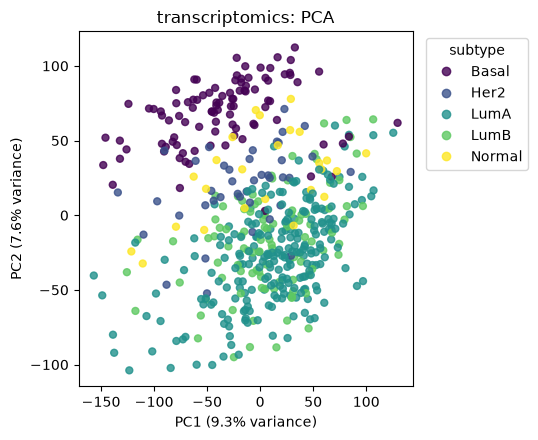

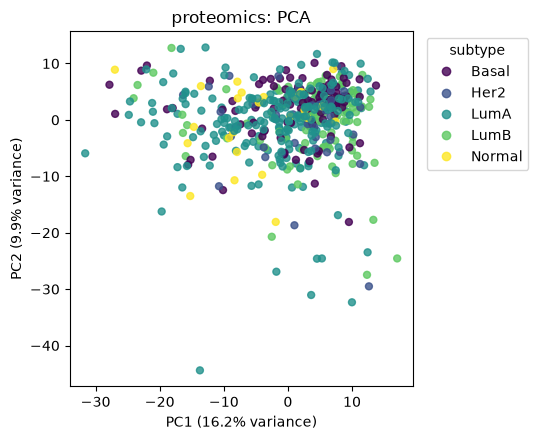

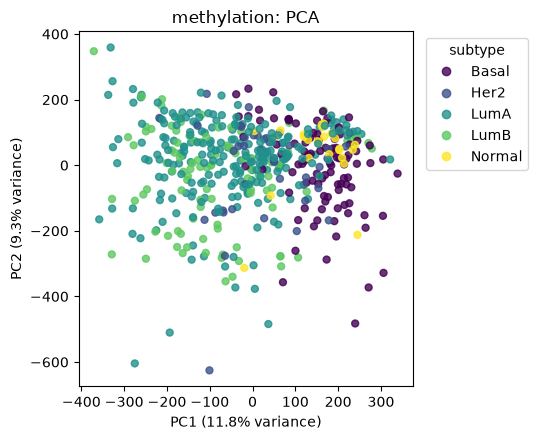

In [5]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
class_names = list(label_encoder.classes_)


def plot_pca_by_omic(X_omics, y_encoded, class_names):
    """Plot the first two PCs for each omic using all patients."""
    for name, X in X_omics.items():
        pca_pipe = Pipeline([
            ("scaler", StandardScaler()),
            ("pca", PCA(n_components=2, random_state=RANDOM_STATE)),
        ])
        scores = pca_pipe.fit_transform(X)
        evr = pca_pipe.named_steps["pca"].explained_variance_ratio_

        plt.figure(figsize=(5.5, 4.5))
        scatter = plt.scatter(scores[:, 0], scores[:, 1], c=y_encoded, s=25, alpha=0.8)
        plt.title(f"{name}: PCA")
        plt.xlabel(f"PC1 ({evr[0]:.1%} variance)")
        plt.ylabel(f"PC2 ({evr[1]:.1%} variance)")
        handles, _ = scatter.legend_elements()
        plt.legend(handles, class_names, title="subtype", bbox_to_anchor=(1.02, 1), loc="upper left")
        plt.tight_layout()
        plt.show()

plot_pca_by_omic(X_omics, y_encoded, class_names)

<details>
<summary><b>Interpretation</b> (click to expand)</summary>

Transcriptomics shows the clearest visible subtype structure: Basal (purple) forms a distinct cluster separated from the LumA/LumB/Normal samples. This suggests that transcriptomic variation contains strong subtype-related signal, which may translate into stronger performance for transcriptomics-based models, although this must be confirmed using supervised prediction.

Proteomics shows weaker visible subtype structure in the first two principal components: samples from different subtypes largely overlap, with only a few outliers separated along PC1. This suggests that subtype-related variation is less dominant in the major variance directions, which may make classification more challenging, although predictive performance must be evaluated directly.

Methylation shows weaker partial structure: some separation along PC1 is visible (Basal/Her2 trending right, LumA/LumB trending left), but subtype groups remain substantially overlapping compared with transcriptomics.

Low variance explained everywhere (7–16% per PC) means these plots are only 2D projections of high-dimensional data. Fine cluster shapes should not be over-interpreted; only broad patterns, such as the stronger subtype separation in transcriptomics, could be considered meaningful.

</details>

## 5. Model helpers

We use the same regularized linear classifier everywhere. Standardization is included inside the pipeline so scaling is learned only from the training data.

In [6]:
def make_linear_classifier(): 
    """Regularized linear model for high-dimensional omics classification."""
    return Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            C=1.0,
            l1_ratio=0,        # equivalent to L2
            solver="lbfgs", #instead of liblinear because it doesn't handle 3+ classes
            class_weight="balanced",
            max_iter=2000,
            random_state=RANDOM_STATE,
        ),
        ),
    ])

def evaluate_predictions(model_name, y_true, y_pred):
    """Return the metrics used throughout the tutorial."""
    return {
        "model": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
    }


def fit_predict(model, X_train, y_train, X_test):
    """Fit a model and return class predictions and probabilities for the test set."""
    fitted = clone(model).fit(X_train, y_train)
    pred = pd.Series(fitted.predict(X_test), index=X_test.index, name="prediction")
    proba = pd.DataFrame(fitted.predict_proba(X_test), index=X_test.index, columns=fitted.classes_)
    return fitted, pred, proba

## 6. Single-omic benchmarks

**Why integrate in the first place?**

Before integrating data types, measure how far each omic gets on its own..

Before comparing integration strategies, we need a reason to integrate in the first place. Each omic layer below is trained as a standalone linear classifier, using the *same* train/test split, model, and metrics as every method that follows.

The question isn't "which single omic is best?"; it's whether the omics agree with each other or not. If every omic already predicted the same subtype for every patient, integration would add complexity without adding information. If they disagree on a meaningful fraction of patients, that disagreement is exactly the signal integration is trying to recover.

In [7]:
results = []
single_omic_models = {}
single_omic_probabilities = {}

base_model = make_linear_classifier()

for name, X in X_omics.items():
    model, pred, proba = fit_predict(
        base_model,
        X.loc[train_ids],
        y_train,
        X.loc[test_ids],
    )
    single_omic_models[name] = model
    single_omic_probabilities[name] = proba
    results.append(evaluate_predictions(f"single omic: {name}", y_test, pred))

results_df = pd.DataFrame(results).sort_values("balanced_accuracy", ascending=False)
results_df

,model,accuracy,balanced_accuracy
0,single omic: transcriptomics,0.768,0.669453
2,single omic: methylation,0.712,0.586340
1,single omic: proteomics,0.680,0.564209


In [8]:
# How often do the single-omic models actually agree on a prediction?
single_omic_preds = {
    name: single_omic_models[name].predict(X_omics[name].loc[test_ids])
    for name in X_omics
}
pred_table = pd.DataFrame(single_omic_preds, index=test_ids)
pred_table["true_label"] = y_test

n_unique_preds = pred_table[list(X_omics)].nunique(axis=1)
agreement_summary = pd.DataFrame({
    "n_patients": [
        (n_unique_preds == 1).sum(),
        (n_unique_preds > 1).sum(),
    ],
}, index=["all omics agree", "omics disagree"])
agreement_summary["pct"] = (100 * agreement_summary["n_patients"] / len(test_ids)).round(1)

print(f"Test patients where every omic predicts the same subtype: "
      f"{agreement_summary.loc['all omics agree', 'pct']}%")
display(agreement_summary)

# Look at a few disputed patients: does any single omic get the true label right
# where others miss it? This is the concrete case for integration.
disputed = pred_table.loc[n_unique_preds > 1].copy()
disputed["any_omic_correct"] = disputed[list(X_omics)].eq(disputed["true_label"], axis=0).any(axis=1)
print(f"Of the disputed patients, {disputed['any_omic_correct'].mean():.0%} "
      f"have at least one omic that got the true subtype right.")
disputed.head(10)

Test patients where every omic predicts the same subtype: 64.8%


,n_patients,pct
all omics agree,81,64.8
omics disagree,44,35.2


Of the disputed patients, 89% have at least one omic that got the true subtype right.


,transcriptomics,proteomics,methylation,true_label,any_omic_correct
TCGA-EW-A2FW,LumB,LumA,LumA,LumB,True
TCGA-E9-A5UO,LumB,LumA,LumB,LumB,True
TCGA-E9-A3QA,Basal,Normal,Basal,Basal,True
TCGA-E9-A1N3,LumA,LumB,LumA,LumA,True
TCGA-BH-A203,Her2,Her2,Normal,Her2,True
TCGA-LQ-A4E4,LumA,LumA,Normal,LumA,True
TCGA-AR-A1AT,Her2,Her2,LumB,Her2,True
TCGA-BH-A1EO,LumA,LumB,LumA,LumA,True
TCGA-C8-A8HR,Normal,LumA,LumA,Normal,True
TCGA-OL-A5RZ,Her2,Basal,Her2,Her2,True


<details>
<summary><b>Interpretation</b> (click to expand)</summary>

We asked each omic to predict the subtype alone. 
On 65% of patients, all three omics agree. These represent cases where each modality provides consistent information, so integration may provide less additional benefit compared with cases where the omics disagree. 

In the remaining 35%, the predictions disagree, suggesting that different omics capture different aspects of the underlying biology or contain different levels of uncertainty for those patients. 

In 89% of disagreement cases, at least one omic-specific model correctly predicted the subtype.The signal was not absent; it was distributed across modalities, with no single omic capturing all of the relevant information consistently.

Therefore, the goal is not simply to identify the "best" omic, but to build models that can combine these partial views into an integrated representation that captures information from multiple sources.

</details>

## 7. Early integration by concatenation

**What's the simplest way to to combine multi omics, and at what does this simplicity cost us?**

Early integration joins all omic features into one wide matrix and trains one classifier.

This is easy and often strong, but it increases dimensionality and does not explicitly distinguish shared, redundant, and omic-specific signal.

In [9]:
def prefix_columns(X: pd.DataFrame, omic_name: str) -> pd.DataFrame:
    """Add an omic prefix so features remain traceable after concatenation."""
    X_prefixed = X.copy()
    X_prefixed.columns = [f"{omic_name}::{col}" for col in X.columns]
    return X_prefixed

X_early = pd.concat(
    [prefix_columns(X, name) for name, X in X_omics.items()],
    axis=1,
)

print(f"Early integration matrix: {X_early.shape[0]} patients x {X_early.shape[1]} features")

early_model, early_pred, early_proba = fit_predict(
    base_model,
    X_early.loc[train_ids],
    y_train,
    X_early.loc[test_ids],
)

results.append(evaluate_predictions("early integration: concatenation", y_test, early_pred))
results_df = pd.DataFrame(results).sort_values("balanced_accuracy", ascending=False)
results_df

Early integration matrix: 500 patients x 230459 features


,model,accuracy,balanced_accuracy
0,single omic: transcriptomics,0.768,0.669453
3,early integration: concatenation,0.744,0.646617
2,single omic: methylation,0.712,0.586340
1,single omic: proteomics,0.680,0.564209


<details>
<summary><b>Interpretation</b> (click to expand)</summary>

Transcriptomics alone is the best performer (0.669 balanced accuracy), outperforming the other single-omic models and the concatenated model.

Early integration underperforms transcriptomics alone (0.647 vs 0.669), showing that simply combining all modalities does not guarantee improved prediction. Additional omic features may introduce redundant or noisy information that the model must separate from the strongest signal.


</details>

## 8. Inspect feature usage in the early-integration model

**When early integration works, does it actually use all omics or lean on one?**


Concatenating features gives the model access to everything at once, but access isn't the same as use. Before trusting an early-integration result, it's worth checking which omics its largest coefficients actually come from. A linear model on concatenated features can be inspected directly through coefficient magnitude, so this is a cheap, concrete check rather than a guess: does the top-100 coefficient list spread across omics, or does one omic quietly dominate?

This matters for what comes next: if early integration turns out to lean on a single omic, that is itself an argument for late integration (Section 9 onward) --> keeping omics as separate models makes this kind of imbalance visible and controllable (via weights) instead of hidden inside one shared coefficient vector.


,omic,features_in_top_100
0,transcriptomics,54
1,methylation,29
2,proteomics,17


,feature,abs_coefficient,omic
30370,proteomics::RICTOR,0.003854,proteomics
223955,methylation::cg26591149,0.003646,methylation
5914,transcriptomics::ENSG00000129484.14,0.003512,transcriptomics
21761,transcriptomics::ENSG00000241359.1,0.003263,transcriptomics
30347,proteomics::PLK1,0.003251,proteomics
6421,transcriptomics::ENSG00000132972.19,0.003139,transcriptomics
13759,transcriptomics::ENSG00000179826.7,0.003078,transcriptomics
30247,proteomics::MCT4,0.003005,proteomics
30119,proteomics::CYCLINB1,0.002995,proteomics
226358,methylation::cg10353539,0.002944,methylation


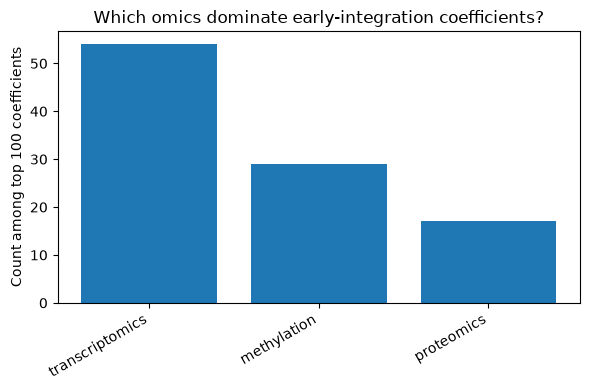

In [10]:
def early_feature_importance(fitted_pipeline, feature_names):
    """Extract maximum absolute coefficient per feature."""
    coefficients = fitted_pipeline.named_steps["model"].coef_
    importance = np.abs(coefficients).max(axis=0)

    feature_importance = pd.DataFrame({
        "feature": feature_names,
        "abs_coefficient": importance,
    })
    feature_importance["omic"] = feature_importance["feature"].str.split("::", n=1).str[0]
    return feature_importance.sort_values("abs_coefficient", ascending=False)

feature_importance = early_feature_importance(early_model, X_early.columns)

TOP_N = min(100, len(feature_importance))
top_feature_usage = (
    feature_importance.head(TOP_N)["omic"]
    .value_counts()
    .rename_axis("omic")
    .reset_index(name=f"features_in_top_{TOP_N}")
)

display(top_feature_usage)
display(feature_importance.head(20))

plt.figure(figsize=(6, 4))
plt.bar(top_feature_usage["omic"], top_feature_usage[f"features_in_top_{TOP_N}"])
plt.ylabel(f"Count among top {TOP_N} coefficients")
plt.title("Which omics dominate early-integration coefficients?")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

<details>
<summary><b>Interpretation</b> (click to expand)</summary>

Proteomics has a compact feature space (464 proteins), so individual features contribute relatively more weight compared with larger omics. However, its weaker standalone performance suggests that these features capture only part of the subtype signal. The presence of proteomic features among the top-ranked predictors means that proteomics may provide complementary information rather than being uninformative.


Transcriptomics has both the strongest standalone predictive performance and the largest contribution among highly weighted features (54% of the top 100). Its dominance is therefore not explained by feature count alone; it reflects a strong subtype-associated signal distributed across many genes.


Methylation has the largest feature space (~200,000 CpG sites), but only 29% of the top 100 features are methylation-derived. This suggests that predictive methylation signal may be sparse and distributed across a small subset of sites, making it harder for simple models to identify without additional structure or feature selection.

</details>

## 9. Cross-omic redundancy among highly weighted features

**Among the top features we just found, are different omics contributing genuinely independent information, or are some of them just correlated proxies for the same underlying signal, counted twice?**

Concatenation does not model correlation between features — it has no way to know that a transcript and a protein it produces are, biologically, close to the same variable measured twice. If the top weighted features from two omics turn out to be highly correlated with each other, the model isn't combining three independent views of the tumor; it's partly double-counting one view. That's a second, more specific way early integration's flexibility can work against it (the first was Section 8's single-omic dominance), and it further motivates keeping omics as separate, explicitly weighted models in the next section.

,feature_1,feature_2,omic_pair,abs_correlation
875,proteomics::CYCLINB1,transcriptomics::ENSG00000112312.10,proteomics ↔ transcriptomics,0.502320
835,proteomics::PLK1,transcriptomics::ENSG00000112312.10,proteomics ↔ transcriptomics,0.447045
955,proteomics::FOXM1,transcriptomics::ENSG00000112312.10,proteomics ↔ transcriptomics,0.443450
895,proteomics::CDK1_pT14,transcriptomics::ENSG00000112312.10,proteomics ↔ transcriptomics,0.424422
838,proteomics::PLK1,transcriptomics::ENSG00000127589.4,proteomics ↔ transcriptomics,0.410333
878,proteomics::CYCLINB1,transcriptomics::ENSG00000127589.4,proteomics ↔ transcriptomics,0.396262
860,proteomics::CYCLINB1,transcriptomics::ENSG00000129484.14,proteomics ↔ transcriptomics,0.389710
898,proteomics::CDK1_pT14,transcriptomics::ENSG00000127589.4,proteomics ↔ transcriptomics,0.384738
820,proteomics::PLK1,transcriptomics::ENSG00000129484.14,proteomics ↔ transcriptomics,0.381803
1035,proteomics::Aurora-A,transcriptomics::ENSG00000112312.10,proteomics ↔ transcriptomics,0.381245


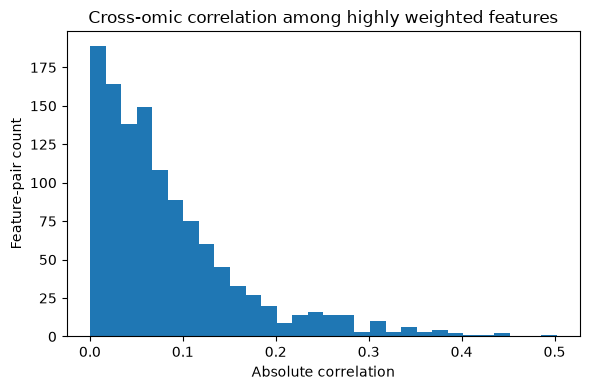

In [11]:
def top_features_per_omic(feature_importance, n_per_omic=20):
    """Return the top coefficient features within each omic."""
    selected = []
    for _, group in feature_importance.groupby("omic"):
        selected.extend(group.head(n_per_omic)["feature"].tolist())
    return selected

selected_features = top_features_per_omic(feature_importance, n_per_omic=20)
X_selected = X_early.loc[:, selected_features]

corr = X_selected.corr().abs()
rows = []

for i, feature_1 in enumerate(corr.columns):
    omic_1 = feature_1.split("::", 1)[0]
    for feature_2 in corr.columns[i + 1:]:
        omic_2 = feature_2.split("::", 1)[0]
        if omic_1 != omic_2:
            rows.append({
                "feature_1": feature_1,
                "feature_2": feature_2,
                "omic_pair": f"{omic_1} ↔ {omic_2}",
                "abs_correlation": corr.loc[feature_1, feature_2],
            })

cross_omic_corr = pd.DataFrame(rows).sort_values("abs_correlation", ascending=False)
display(cross_omic_corr.head(20))

plt.figure(figsize=(6, 4))
plt.hist(cross_omic_corr["abs_correlation"], bins=30)
plt.xlabel("Absolute correlation")
plt.ylabel("Feature-pair count")
plt.title("Cross-omic correlation among highly weighted features")
plt.tight_layout()
plt.show()

<details>
<summary><b>Interpretation</b> (click to expand)</summary>

The highly weighted features from early integration show moderate cross-omic correlation, concentrated mainly between proteomics and transcriptomics. This pattern is consistent with shared biological processes being captured at both the RNA and protein levels. In contrast, methylation features show less overlap with these highly weighted features, suggesting that they may provide more distinct information.

These results suggest that early integration may treat correlated features across modalities as separate sources of evidence rather than explicitly recognizing their shared biological origin. In this dataset, concatenation may therefore capture redundant signals alongside complementary ones.

→ Early integration cannot distinguish complementary signal from redundant signal automatically. To address this, we next test approaches that keep omics separate and combine their predictions through late integration.

</details>

## 10. Late integration by prediction averaging

**Instead of merging features, what if we let each omic make its own prediction and then vote — and how much does the voting rule matter?**

Late integration trains one model per omic and averages the class probabilities. Each omic gets an equal vote by default.This sidesteps the dimensionality problem of early integration and keeps each omic's model easy to inspect on its own, but it assumes equal weighting is the right call, an assumption we will stress-test later.

In [12]:
def late_integrated_probabilities(probability_tables, weights=None):
    """Average same-index, same-column probability tables from omic-specific models."""
    weights = weights or {name: 1.0 for name in probability_tables}
    weight_total = sum(weights.values())

    averaged = None
    for name, proba in probability_tables.items():
        weighted_proba = proba * weights[name]
        averaged = weighted_proba if averaged is None else averaged + weighted_proba

    return averaged / weight_total

late_proba = late_integrated_probabilities(single_omic_probabilities)
late_pred = late_proba.idxmax(axis=1).rename("prediction")

results.append(evaluate_predictions("late integration: equal weights", y_test, late_pred))
results_df = pd.DataFrame(results).sort_values("balanced_accuracy", ascending=False)
results_df

,model,accuracy,balanced_accuracy
0,single omic: transcriptomics,0.768,0.669453
3,early integration: concatenation,0.744,0.646617
4,late integration: equal weights,0.752,0.637492
2,single omic: methylation,0.712,0.586340
1,single omic: proteomics,0.680,0.564209


What is your interpretation of these results?

<details>
<summary><b>Interpretation</b> (click to expand)</summary>

Late integration with equal weights did not improve performance (balanced accuracy = 0.637), falling below transcriptomics alone (0.669) and even below early integration (0.647). This suggests that treating all omics as equally informative is not optimal for this dataset.

Transcriptomics provides the strongest standalone signal, while proteomics and methylation contribute weaker predictions. Equal-weight averaging assumes that each modality provides equally reliable information, so the weaker omic predictions may dilute the stronger transcriptomic signal rather than enhance it.

However, this does not mean that proteomics or methylation are uninformative. Their disagreement with transcriptomics may reflect complementary information that is not captured by a simple averaging rule. A learned integration approach could allow the model to determine how much each modality should contribute rather than imposing equal weights.

</details>

## 11. Late-integration weight sensitivity

**How much does the (essentially arbitrary) choice of omic weights actually change the outcome — and could we have learned better weights instead?**

Equal weighting is simple, but it encodes a strong assumption: each omic should contribute equally. This small test boosts one omic at a time and checks whether the held-out accuracy changes. If it does, equal weighting was an arbitrary choice, not a principled one — which is exactly what the next section addresses by learning the weights instead of guessing them.

,weighting,accuracy,balanced_accuracy
2,boost proteomics,0.768,0.644271
1,boost transcriptomics,0.760,0.640881
0,equal weights,0.752,0.637492
3,boost methylation,0.736,0.627283


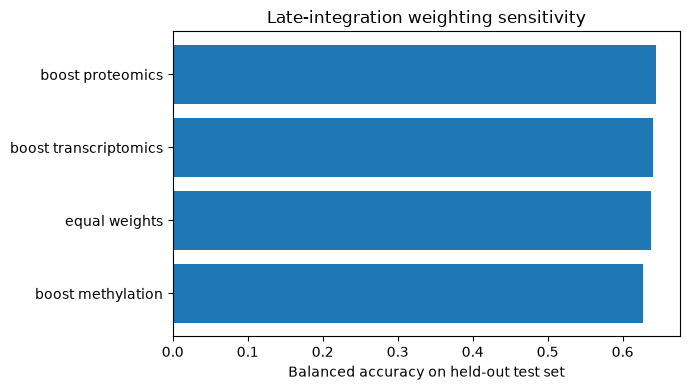

In [13]:
weight_rows = []
base_weights = {name: 1.0 for name in X_omics}

# Equal weights.
proba = late_integrated_probabilities(single_omic_probabilities, weights=base_weights)
pred = proba.idxmax(axis=1)
weight_rows.append({
    "weighting": "equal weights",
    **evaluate_predictions("late", y_test, pred),
})

# Boost each omic while keeping the same trained single-omic models and same test split.
for boosted_omic in X_omics:
    weights = base_weights.copy()
    weights[boosted_omic] = 2.0
    proba = late_integrated_probabilities(single_omic_probabilities, weights=weights)
    pred = proba.idxmax(axis=1)
    weight_rows.append({
        "weighting": f"boost {boosted_omic}",
        **evaluate_predictions("late", y_test, pred),
    })

weight_sensitivity = (
    pd.DataFrame(weight_rows)
    .drop(columns="model")
    .sort_values("balanced_accuracy", ascending=False)
)

display(weight_sensitivity)

plt.figure(figsize=(7, 4))
plt.barh(weight_sensitivity["weighting"], weight_sensitivity["balanced_accuracy"])
plt.xlabel("Balanced accuracy on held-out test set")
plt.title("Late-integration weighting sensitivity")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()



<details>
<summary><b>Interpretation</b> (click to expand)</summary>

All fixed weighting schemes perform within a narrow range (balanced accuracy = 0.627–0.644), indicating that manual adjustments to modality weights produce only modest changes compared with equal weighting.

The best fixed-weight result comes from boosting proteomics (0.644), despite proteomics being the weakest standalone predictor (0.564). Conversely, boosting transcriptomics, the strongest individual modality (0.669), provides only a small improvement over equal weighting (0.641 vs 0.637), while increasing methylation contribution reduces performance (0.627).

This demonstrates that standalone predictive performance does not determine how much a modality should contribute during multimodal integration. A weaker modality may still provide complementary information when combined with stronger modalities, while a strong modality may already capture overlapping signal.

Fixed weighting is therefore a limited approach for our dataset: the optimal contribution of each modality cannot be reliably inferred from single-omic performance alone. Instead, a learned fusion strategy can adaptively determine how different modality-specific predictions should contribute to the final decision.


</details>

## 12. Late integration, take two — stacking (a learned combiner)

**Key question:** could we replace the guessed, fixed weights of equal-weight averaging with weights the data itself tells us to use?

The previous section showed that equal-weight averaging is sensitive to a choice we can't justify from data alone. Stacking keeps the same "one model per omic" structure, but replaces the fixed averaging rule with a second linear model that *learns* how much each omic contributes per class. It's still late integration in the strict sense (each omic still collapses to an independent prediction before anything cross-omic happens) but the combining rule is now learned rather than assumed.

To avoid leaking test information into the meta-learner, the per-omic probabilities used to train it are computed out-of-fold on the training set (cross-validated), not from models that have already seen the training labels. At test time we reuse the same single-omic models and probabilities from Section 6.


In [ ]:
from sklearn.model_selection import cross_val_predict

N_FOLDS = 5

def out_of_fold_probabilities(model, X_train, y_train, class_names, n_folds=N_FOLDS):
    """Cross-validated (leakage-free) train-set probabilities for meta-learner training."""
    oof = cross_val_predict(
        clone(model), X_train, y_train, cv=n_folds, method="predict_proba"
    )
    return pd.DataFrame(oof, index=X_train.index, columns=sorted(y_train.unique()))[class_names]

meta_train_blocks = []
for name, X in X_omics.items():
    oof_proba = out_of_fold_probabilities(base_model, X.loc[train_ids], y_train, class_names)
    oof_proba.columns = [f"{name}::{c}" for c in oof_proba.columns]
    meta_train_blocks.append(oof_proba)
meta_X_train = pd.concat(meta_train_blocks, axis=1)

meta_test_blocks = []
for name in X_omics:
    proba = single_omic_probabilities[name][class_names].copy()
    proba.columns = [f"{name}::{c}" for c in class_names]
    meta_test_blocks.append(proba)
meta_X_test = pd.concat(meta_test_blocks, axis=1)

meta_model = LogisticRegression(
    l1_ratio=0, C=1.0, solver="lbfgs", class_weight="balanced",
    max_iter=2000, random_state=RANDOM_STATE,
)
meta_model.fit(meta_X_train, y_train)
stacked_pred = pd.Series(meta_model.predict(meta_X_test), index=test_ids, name="prediction")

results.append(evaluate_predictions("late integration: stacking (meta-learner)", y_test, stacked_pred))
results_df = pd.DataFrame(results).sort_values("balanced_accuracy", ascending=False)
results_df

In [ ]:
# Unlike late integration's fixed weights, stacking's learned coefficients show
# how much the meta-learner trusts each omic, per predicted subtype.
meta_coefs = pd.DataFrame(
    meta_model.coef_, index=meta_model.classes_, columns=meta_X_train.columns
)
meta_coefs.columns = pd.MultiIndex.from_tuples(
    [tuple(col.split("::")) for col in meta_coefs.columns], names=["omic", "class"]
)

#magnitude of reliance
meta_coefs.abs().T.groupby(level="omic").mean().T.round(2)

omic,methylation,proteomics,transcriptomics
Basal,0.53,0.63,0.64
Her2,0.64,0.50,1.07
LumA,0.24,0.60,0.75
LumB,0.78,0.56,0.54
Normal,0.73,0.35,1.08


<details>
<summary><b>Interpretation</b> (click to expand)</summary>

The stacking model does not assign one fixed contribution to each omic. Instead, the meta-model learns subtype-specific contributions for each modality prediction, allowing different omics to influence different classification decisions.

For example, transcriptomics receives larger coefficients for Her2 and Normal predictions compared with methylation, while its contribution is closer to proteomics for Basal and LumA. This type of class-specific flexibility cannot be captured by equal-weight late integration, which assumes that all modalities contribute equally across all predictions.

These coefficients illustrate why learned fusion can be advantageous: the optimal contribution of each modality depends on the prediction context rather than being determined solely by standalone performance. However, these coefficients describe prediction combination rather than direct biological importance of each omic.


</details>

## 13. Compare all linear methods

**After all that, did integration actually beat the best single omic? And which integration strategy "won" ?** 

A genuine improvement here justifies the added complexity of early, late, or stacked integration. A tie (or a loss) can be just as informative; it tells you that the extra modeling complexity is not justified for this dataset.

,model,accuracy,balanced_accuracy
5,late integration: stacking (meta-learner),0.768,0.699245
0,single omic: transcriptomics,0.768,0.669453
3,early integration: concatenation,0.744,0.646617
4,late integration: equal weights,0.752,0.637492
2,single omic: methylation,0.712,0.586340
1,single omic: proteomics,0.680,0.564209


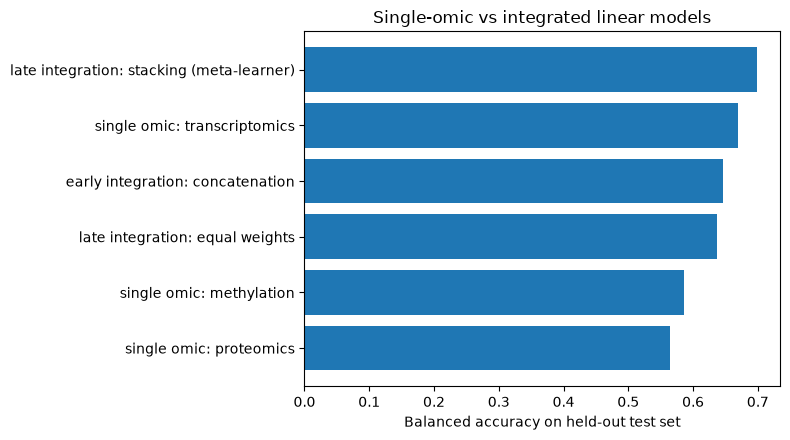

In [ ]:
summary = pd.DataFrame(results).sort_values("balanced_accuracy", ascending=True)
display(summary.sort_values("balanced_accuracy", ascending=False))

plt.figure(figsize=(8, 4.5))
plt.barh(summary["model"], summary["balanced_accuracy"])
plt.xlabel("Balanced accuracy on held-out test set")
plt.title("Single-omic vs integrated linear models")
plt.tight_layout()
plt.show()

<details>
<summary><b>Interpretation</b> (click to expand)</summary>

Naive integration strategies did not improve over the strongest single-omic model in this benchmark. Early integration through concatenation (0.647 balanced accuracy) and late integration through equal-weight averaging (0.637) both performed below transcriptomics alone (0.669), suggesting that simply combining modalities does not guarantee improved prediction.

In contrast, stacking achieved the highest performance (0.699 balanced accuracy), exceeding transcriptomics alone by learning how to combine modality-specific predictions rather than applying a fixed fusion rule. The learned combination allows different omics to contribute differently depending on the classification context, capturing complementary information that was not fully exploited by simpler integration strategies.

This result demonstrates that the challenge in multi-omics integration is not simply adding more data, but learning how different modalities should contribute to the final prediction.

</details>

## 14. Confusion matrix and classification report

Use this section to discuss which subtypes are easier or harder for the best simple model.

In [ ]:
best_model_name = results_df.iloc[0]["model"]
print(f"Best model by balanced accuracy: {best_model_name}")

if best_model_name == "early integration: concatenation":
    best_pred = early_pred
elif best_model_name == "late integration: equal weights":
    best_pred = late_pred
elif best_model_name == "late integration: stacking (meta-learner)":
    best_pred = stacked_pred
else:
    best_omic = best_model_name.split(": ", 1)[1]
    best_pred = single_omic_models[best_omic].predict(X_omics[best_omic].loc[test_ids])
    best_pred = pd.Series(best_pred, index=test_ids)
    
cm = pd.DataFrame(
    confusion_matrix(y_test, best_pred, labels=class_names),
    index=[f"true: {c}" for c in class_names],
    columns=[f"pred: {c}" for c in class_names],
)

display(cm)
print(classification_report(y_test, best_pred))

Best model by balanced accuracy: late integration: stacking (meta-learner)


,pred: Basal,pred: Her2,pred: LumA,pred: LumB,pred: Normal
true: Basal,24,0,0,0,0
true: Her2,0,9,0,1,0
true: LumA,0,0,49,10,0
true: LumB,0,1,12,12,0
true: Normal,2,1,2,0,2


              precision    recall  f1-score   support

       Basal       0.92      1.00      0.96        24
        Her2       0.82      0.90      0.86        10
        LumA       0.78      0.83      0.80        59
        LumB       0.52      0.48      0.50        25
      Normal       1.00      0.29      0.44         7

    accuracy                           0.77       125
   macro avg       0.81      0.70      0.71       125
weighted avg       0.77      0.77      0.76       125



<details>
<summary><b>Interpretation</b> (click to expand)</summary>

The stacked model separates Basal and Her2 very well, with near-perfect recall for both classes. This suggests that these subtypes contain strong predictive signals that are consistently captured across the integrated modality predictions.

The main challenge is distinguishing LumA from LumB. These subtypes show substantial overlap, with many LumB samples classified as LumA, consistent with the idea that these molecular subtypes represent a biological continuum rather than completely distinct categories.

The Normal class shows high precision but low recall: when the model predicts Normal it is usually correct, but it misses many true Normal samples. This likely reflects both the limited number of Normal samples available (only 7 test patients) and the difficulty of learning a minority class with few examples.

Overall, this demonstrates that integration strategy can improve how information is combined across omics, but it cannot compensate for limited sample size, class imbalance, or intrinsically overlapping biological categories.

</details>

## Summary

<table>
  <colgroup>
    <col style="width:15%">
    <col style="width:45%">
    <col style="width:15%">
    <col style="width:10%">
    <col style="width:15%">
  </colgroup>
  <thead>
    <tr>
      <th>Strategy</th>
      <th>Data Flow</th>
      <th>Integration Point</th>
      <th>Output</th>
      <th>Key Characteristic</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td><strong>Early Integration</strong></td>
      <td>RNA-seq + Methylation + Proteomics → <strong>Combine</strong></td>
      <td>Before training</td>
      <td>One feature matrix</td>
      <td>All modalities are merged into a single input representation.</td>
    </tr>
    <tr>
      <td><strong>Late Integration</strong></td>
      <td>
        RNA-seq → Model<br>
        Methylation → Model<br>
        Proteomics → Model → <strong>Average predictions</strong>
      </td>
      <td>After prediction</td>
      <td>Combined prediction</td>
      <td>Each modality is modeled independently before combining predictions.</td>
    </tr>
    <tr>
      <td><strong>Stacking</strong></td>
      <td>
        RNA-seq → Model<br>
        Methylation → Model<br>
        Proteomics → Model → <strong>Meta-model</strong>
      </td>
      <td>Meta-learning</td>
      <td>Final prediction</td>
      <td>Learns the optimal way to combine modality-specific model outputs.</td>
    </tr>
  </tbody>
</table>

## Takeaways

1. **Different omics capture different aspects of biological variation.** PCA provides a visual entry point for comparing how modalities represent sample structure and where shared or distinct patterns may exist.

2. **Single-omic models are essential baselines.** Integration should be evaluated against individual modalities to determine whether combining data provides additional value beyond single sources.

3. **Early integration is simple but assumes features can be combined directly.** Concatenation creates a unified feature space, allowing models to use information across omics simultaneously. However, it does not explicitly model relationships between modalities, so correlated features may be treated as independent evidence.

4. **Predictive features are not necessarily independent features.** Correlated features across omics can represent shared biological processes, meaning that high feature importance does not automatically indicate unique information.

5. **Late integration is interpretable but depends on the fusion rule.** Combining modality-specific predictions keeps models separate and easier to interpret, but fixed weighting schemes may not capture differences in modality reliability.

6. **Stacking provides a more adaptive form of late integration.** Instead of fixing how modalities contribute, a meta-model learns how to combine modality-specific predictions from the data.

7. **Classical integration methods do not explicitly model cross-omic feature relationships.** This limitation motivates approaches that learn shared structure across modalities, covered next in Part 2.

8. The goal is not to find the most complex integration method, but the method whose assumptions match the data and biological question.


## Bridge to the next part

None of the classical integration methods we just learned explicitly model relationships between features across omics. Feature concatenation places all features into a shared space but does not account for redundancy or structured relationships between modalities (which is why proteomics/transcriptomics redundancy in Section 9 was not apparent until we examined feature relationships directly). Prediction averaging and stacking address this limitation indirectly; they combine modality-specific predictions without examining the feature-level relationships that generated them.

A method that models cross-omic relationships directly could separate shared signal (such as the genes we found correlated across proteomics and transcriptomics) from genuinely omic-specific variation. This avoids treating redundant features as independent evidence during early integration or relying only on prediction-level combinations during stacking. That is precisely what the next session introduces: methods that learn shared latent factors directly from cross-omic covariance, making the redundancy we identified manually an explicit, modeled part of the representation rather than a blind spot.

These approaches are not necessarily "better" than classical integration methods; they make different assumptions about where useful information exists in the data. Their advantage comes from being able to model shared and modality-specific structure explicitly when those relationships are important for the biological question.

This moves us towards generating an integrated multi-omic profile for each patient, where shared and modality-specific biological signals can be represented explicitly.